In [1]:
# Import Libraries
# ============================================================================

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    precision_recall_curve, auc, f1_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("DECISION TREE MODEL - TRAINING")
print("="*80)
print()

DECISION TREE MODEL - TRAINING



In [12]:
# Load Preprocessed Data
# ============================================================================

print("Loading preprocessed data...")

with open('./preprocessed_data/X_train_smote.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open('./preprocessed_data/y_train_smote.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open('./preprocessed_data/X_val_processed.pkl', 'rb') as f:
    X_val = pickle.load(f)
with open('./preprocessed_data/y_val.pkl', 'rb') as f:
    y_val = pickle.load(f)
with open('./preprocessed_data/X_test_processed.pkl', 'rb') as f:
    X_test = pickle.load(f)

print(f"✓ X_train shape: {X_train.shape}")
print(f"✓ y_train distribution: {np.bincount(y_train)}")
print(f"✓ X_val shape: {X_val.shape}")
print(f"✓ X_test shape: {X_test.shape}")
print()

# =============================================================================
# CHECK DATA TYPES
# =============================================================================
print("Checking data types...")
print("X_train:", type(X_train))
print("X_val:", type(X_val))
print("X_test:", type(X_test))
print()

# =============================================================================
# ENSURE DATA IS IN DATAFRAME FORMAT
# =============================================================================
if not isinstance(X_train, pd.DataFrame):
    print("Converting NumPy arrays to DataFrames...")
    
    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]
    
    X_train = pd.DataFrame(X_train, columns=feature_names)
    X_val = pd.DataFrame(X_val, columns=feature_names)
    X_test = pd.DataFrame(X_test, columns=feature_names)
    
    print("✓ Conversion complete!")
    print()

# =============================================================================
# FEATURE MISMATCH CHECK
# =============================================================================
print("Feature mismatch check:")

missing = set(X_train.columns) - set(X_val.columns)
extra = set(X_val.columns) - set(X_train.columns)

print("Missing in val:", len(missing))
print("Extra in val:", len(extra))
print()

Loading preprocessed data...
✓ X_train shape: (911804, 387)
✓ y_train distribution: [455902 455902]
✓ X_val shape: (118108, 387)
✓ X_test shape: (506691, 387)

Checking data types...
X_train: <class 'pandas.DataFrame'>
X_val: <class 'pandas.DataFrame'>
X_test: <class 'pandas.DataFrame'>

Feature mismatch check:
Missing in val: 387
Extra in val: 387



In [13]:
# Compute Class Weights for Cost-Sensitive Learning
# ============================================================================

print("Computing class weights for cost-sensitive learning...")

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print(f"Class weights: {class_weight_dict}")
print(f"  Class 0 (Legitimate): {class_weight_dict[0]:.4f}")
print(f"  Class 1 (Fraudulent): {class_weight_dict[1]:.4f}")
print()

Computing class weights for cost-sensitive learning...
Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}
  Class 0 (Legitimate): 1.0000
  Class 1 (Fraudulent): 1.0000



In [14]:
# Train Decision Tree Model
# ============================================================================

print("="*80)
print("TRAINING DECISION TREE")
print("="*80)
print()

dt_model = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
    class_weight=class_weight_dict,
    criterion='gini'
)

dt_model.fit(X_train, y_train)

print("✓ Decision Tree trained successfully!")
print(f"  Tree depth: {dt_model.get_depth()}")
print(f"  Number of leaves: {dt_model.get_n_leaves()}")
print()

TRAINING DECISION TREE

✓ Decision Tree trained successfully!
  Tree depth: 15
  Number of leaves: 1542



In [16]:
# ============================================================================
# Make Predictions
# ============================================================================

print("Making predictions on validation set...")

# =============================================================================
# CRITICAL FIX: ALIGN FEATURES
# =============================================================================
print("Aligning features...")

X_val = X_val.reindex(columns=dt_model.feature_names_in_, fill_value=0)
X_test = X_test.reindex(columns=dt_model.feature_names_in_, fill_value=0)

# Safety check
assert list(X_val.columns) == list(dt_model.feature_names_in_)
assert list(X_test.columns) == list(dt_model.feature_names_in_)

print("✓ Features aligned!")

# =============================================================================
# MAKE PREDICTIONS
# =============================================================================
y_val_pred = dt_model.predict(X_val)
y_val_proba = dt_model.predict_proba(X_val)[:, 1]

y_test_pred = dt_model.predict(X_test)
y_test_proba = dt_model.predict_proba(X_test)[:, 1]

print(f"✓ Validation predictions shape: {y_val_pred.shape}")
print(f"✓ Test predictions shape: {y_test_pred.shape}")
print()

Making predictions on validation set...
Aligning features...
✓ Features aligned!
✓ Validation predictions shape: (118108,)
✓ Test predictions shape: (506691,)



In [17]:
# Evaluation Metrics
# ============================================================================

print("="*80)
print("DECISION TREE - VALIDATION PERFORMANCE")
print("="*80)
print()

print(classification_report(y_val, y_val_pred, target_names=['Legitimate', 'Fraudulent']))

# Calculate metrics
accuracy = (y_val_pred == y_val).sum() / len(y_val)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print()

DECISION TREE - VALIDATION PERFORMANCE

              precision    recall  f1-score   support

  Legitimate       0.00      0.00      0.00    113975
  Fraudulent       0.03      1.00      0.07      4133

    accuracy                           0.03    118108
   macro avg       0.02      0.50      0.03    118108
weighted avg       0.00      0.03      0.00    118108

Accuracy: 0.0350
Precision: 0.0350
Recall: 1.0000
F1-Score: 0.0676
ROC-AUC: 0.5000



Generating Precision-Recall curve...


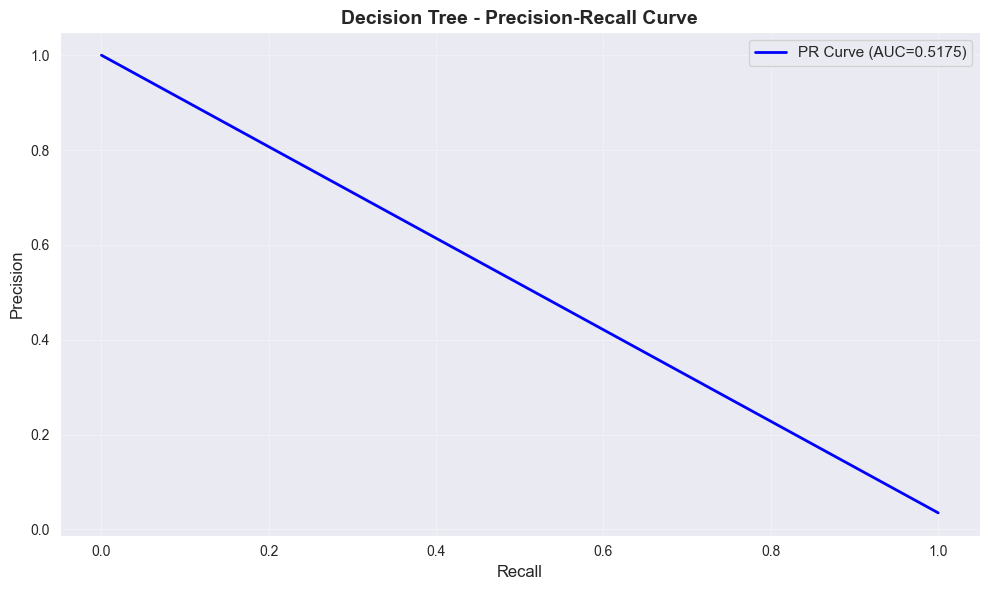

✓ PR-AUC: 0.5175
✓ Saved: dt_precision_recall.png



In [18]:
# Precision-Recall Curve
# ============================================================================

print("Generating Precision-Recall curve...")

precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, y_val_proba)
pr_auc = auc(recall_curve, precision_curve)

plt.figure(figsize=(10, 6))
plt.plot(recall_curve, precision_curve, linewidth=2, label=f'PR Curve (AUC={pr_auc:.4f})', color='blue')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Decision Tree - Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/visualizations/dt_precision_recall.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ PR-AUC: {pr_auc:.4f}")
print(f"✓ Saved: dt_precision_recall.png")
print()

Generating Confusion Matrix...


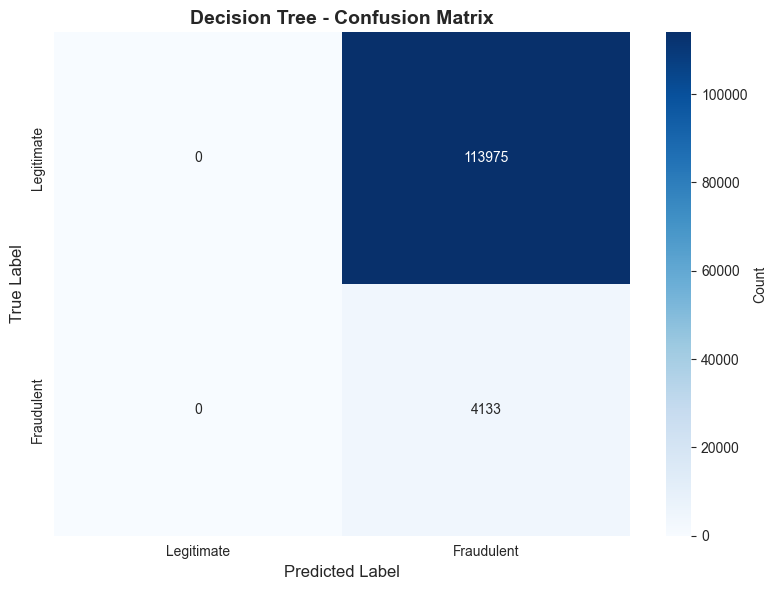

✓ Saved: dt_confusion_matrix.png

True Negatives: 0
False Positives: 113975
False Negatives: 0
True Positives: 4133



In [19]:
# Confusion Matrix
# ============================================================================

print("Generating Confusion Matrix...")

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'],
            cbar_kws={'label': 'Count'})
plt.title('Decision Tree - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('../notebooks/visualizations/dt_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: dt_confusion_matrix.png")
print()

# Parse confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")
print()

In [20]:
# Cost-Benefit Analysis
# ============================================================================

print("="*80)
print("COST-BENEFIT ANALYSIS")
print("="*80)
print()

# Assuming costs
false_negative_cost = 100  # Cost of missing fraud
false_positive_cost = 1    # Cost of false alarm

total_cost = (fn * false_negative_cost) + (fp * false_positive_cost)

print(f"False Negative Cost: ${false_negative_cost}")
print(f"False Positive Cost: ${false_positive_cost}\n")

print(f"True Negatives: {tn}")
print(f"False Positives: {fp} → Cost: ${fp * false_positive_cost}")
print(f"False Negatives: {fn} → Cost: ${fn * false_negative_cost}")
print(f"True Positives: {tp}")
print(f"\nTotal Cost: ${total_cost}")
print()

COST-BENEFIT ANALYSIS

False Negative Cost: $100
False Positive Cost: $1

True Negatives: 0
False Positives: 113975 → Cost: $113975
False Negatives: 0 → Cost: $0
True Positives: 4133

Total Cost: $113975



Calculating feature importance...
Top 15 Important Features:
    Feature  Importance
feature_332    0.223741
feature_296    0.183338
 feature_23    0.135575
 feature_22    0.051988
feature_325    0.048181
 feature_17    0.038185
feature_320    0.033613
feature_318    0.028187
  feature_1    0.027745
 feature_20    0.018361
 feature_13    0.015285
 feature_10    0.013634
 feature_26    0.008446
  feature_0    0.008177
 feature_18    0.007459



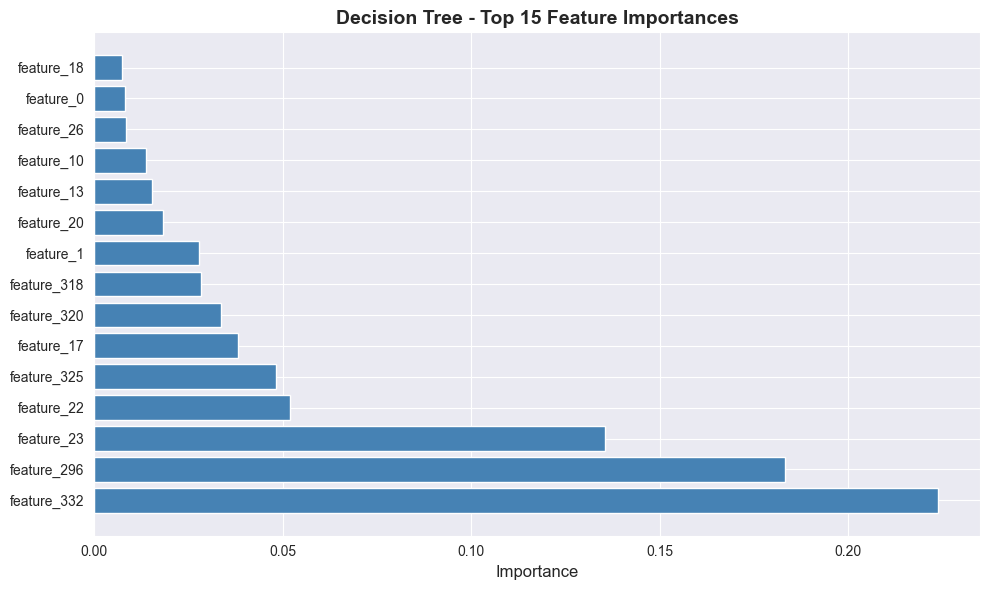

✓ Saved: dt_feature_importance.png



In [21]:
# Feature Importance
# ============================================================================

print("Calculating feature importance...")

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 15 Important Features:")
print(feature_importance.head(15).to_string(index=False))
print()

# Plot feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Decision Tree - Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/visualizations/dt_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: dt_feature_importance.png")
print()

In [22]:
# Save Model
# ============================================================================

print("="*80)
print("SAVING MODEL")
print("="*80)
print()

# Save model
joblib.dump(dt_model, '../models/decision_tree_model.pkl')
print("✓ Model saved: ../models/decision_tree_model.pkl")

# Save model info
model_info = {
    'model_name': 'Decision Tree Classifier',
    'model_type': 'tree-based',
    'validation_accuracy': float(accuracy),
    'validation_precision': float(precision),
    'validation_recall': float(recall),
    'validation_f1': float(f1),
    'validation_roc_auc': float(roc_auc),
    'validation_pr_auc': float(pr_auc),
    'total_cost': float(total_cost),
    'hyperparameters': {
        'max_depth': 15,
        'min_samples_split': 50,
        'min_samples_leaf': 20,
        'criterion': 'gini',
        'class_weight': 'balanced'
    },
    'feature_count': X_train.shape[1],
    'training_samples': len(X_train),
    'validation_samples': len(X_val),
    'test_samples': len(X_test),
    'confusion_matrix': {
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp)
    }
}

with open('../models/decision_tree_model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)

print("✓ Model info saved: ../models/decision_tree_model_info.json")
print()

SAVING MODEL

✓ Model saved: ../models/decision_tree_model.pkl
✓ Model info saved: ../models/decision_tree_model_info.json



In [23]:
# Model Summary
# ============================================================================

print("="*80)
print("DECISION TREE MODEL SUMMARY")
print("="*80)
print()

print("Model Performance:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")
print(f"  PR-AUC:    {pr_auc:.4f}")
print()

print("Cost Analysis:")
print(f"  False Negatives: {fn} (Cost: ${fn * false_negative_cost})")
print(f"  False Positives: {fp} (Cost: ${fp * false_positive_cost})")
print(f"  Total Cost: ${total_cost}")
print()

print("✅ Decision Tree Model Training Complete!")
print()

DECISION TREE MODEL SUMMARY

Model Performance:
  Accuracy:  0.0350
  Precision: 0.0350
  Recall:    1.0000
  F1-Score:  0.0676
  ROC-AUC:   0.5000
  PR-AUC:    0.5175

Cost Analysis:
  False Negatives: 0 (Cost: $0)
  False Positives: 113975 (Cost: $113975)
  Total Cost: $113975

✅ Decision Tree Model Training Complete!

